In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Data points: random vectors of x and y, x sorted
X = np.random.rand(20)*5
Y = np.random.rand(20)*5
X = np.sort(X)

# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

print("X: ",X)
print("Y: ",Y)
print("A: ",A)

X:  [0.11347282 0.27156307 1.30023018 1.59442172 2.0252563  2.19046848
 2.88940463 2.9480638  3.42561757 3.65082683 3.71815414 3.86308591
 4.00547874 4.31128538 4.56193225 4.57333101 4.58962383 4.86184685
 4.93797727 4.98261141]
Y:  [4.01067507 3.66606855 4.9213102  2.23514917 0.80268822 2.47948006
 3.90816392 4.13052493 2.22972011 2.52855463 3.69235241 4.84127437
 0.05260598 4.43206121 1.95783917 1.61657983 1.21517918 1.63961361
 2.46214732 4.13305884]
A:  [[0.11347282 1.        ]
 [0.27156307 1.        ]
 [1.30023018 1.        ]
 [1.59442172 1.        ]
 [2.0252563  1.        ]
 [2.19046848 1.        ]
 [2.88940463 1.        ]
 [2.9480638  1.        ]
 [3.42561757 1.        ]
 [3.65082683 1.        ]
 [3.71815414 1.        ]
 [3.86308591 1.        ]
 [4.00547874 1.        ]
 [4.31128538 1.        ]
 [4.56193225 1.        ]
 [4.57333101 1.        ]
 [4.58962383 1.        ]
 [4.86184685 1.        ]
 [4.93797727 1.        ]
 [4.98261141 1.        ]]


In [2]:
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")
Y2 = m*X+c

Slope: -0.25720866960535216, Intercept: 3.681296861753609


In [3]:
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)
# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)
# Step 3: Use the coefficients to predict y-values (polynomial function)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
print(polynomial)

Polynomial Coefficients:  [-0.05187023  0.44480151 -1.29604961  4.14940927]
          3          2
-0.05187 x + 0.4448 x - 1.296 x + 4.149


In [4]:
y_pred = polynomial(X)

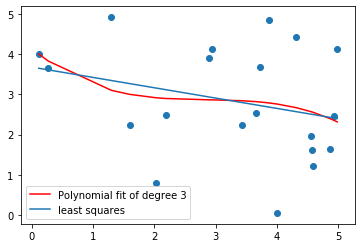

In [5]:
plt.plot(X, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
plt.legend()
plt.show()

In [6]:
mse = np.mean((Y - y_pred)**2)
print(f'Mean Squared Error POLYNOMIAL: {mse:.4f}')

mse = np.mean((Y - Y2)**2)
print(f'Mean Squared Error LEAST SQUARES: {mse:.4f}')

Mean Squared Error POLYNOMIAL: 1.7046
Mean Squared Error LEAST SQUARES: 1.7291


In [7]:
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared POLYNOMIAL: {r_squared:.4f}')

ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - Y2)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared LEAST SQUARES: {r_squared:.4f}')

R-squared POLYNOMIAL: 0.0912
R-squared LEAST SQUARES: 0.0781


The polynomial is a better fit because of the higher R-squared value and the lower MSE, meaning that the curve is a better representation of the data than the straight line.

         4          3         2
0.05333 x - 0.6154 x + 2.354 x - 3.456 x + 4.536


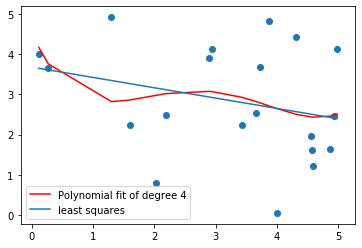

In [8]:
degree = 4 # Degree of the polynomial
coefficients4 = np.polyfit(X, Y, degree)
polynomial4 = np.poly1d(coefficients4)
y_pred4 = polynomial4(X)
print(polynomial4)
plt.plot(X, y_pred4, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
plt.legend()
plt.show()

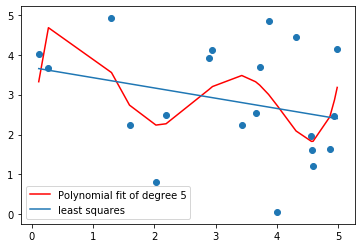

In [9]:
degree = 5 # Degree of the polynomial
coefficients5 = np.polyfit(X, Y, degree)
polynomial5 = np.poly1d(coefficients5)
y_pred5 = polynomial5(X)
plt.plot(X, y_pred5, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
plt.legend()
plt.show()

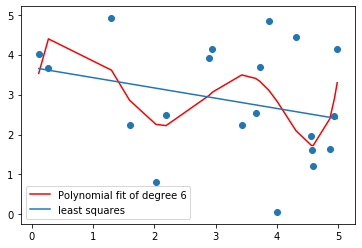

In [10]:
degree = 6 # Degree of the polynomial
coefficients6 = np.polyfit(X, Y, degree)
polynomial6 = np.poly1d(coefficients6)
y_pred6 = polynomial6(X)
plt.plot(X, y_pred6, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
plt.legend()
plt.show()

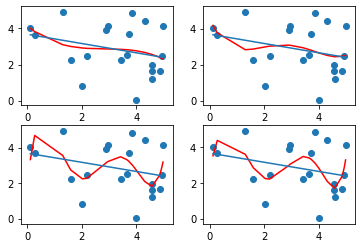

In [11]:
plt.subplot(2, 2, 1) # (row, column, active area)
plt.plot(X, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
# plt.legend()

plt.subplot(2, 2, 2)
plt.plot(X, y_pred4, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
# plt.legend()

plt.subplot(2, 2, 3) # (row, column, active area)
plt.plot(X, y_pred5, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
# plt.legend()

plt.subplot(2, 2, 4)
plt.plot(X, y_pred6, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
# plt.legend()

plt.show()

3rd, 4th, 5th, and 6th degree polynomials shown side by side. It's clear that the 6th degree is overfitting because of the amount it's curving towards the points. Additionally, the end behavior of the polynomial indicates that it's shooting off at a very extreme slope, which is not what the data represents as it's modeled off of a linear equation.

In [12]:
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared 3rd degree POLYNOMIAL: {r_squared:.4f}')

mse = np.mean((Y - y_pred)**2)
print(f'Mean Squared Error 3rd degree POLYNOMIAL: {mse:.4f}')

ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred4)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared 4th degree POLYNOMIAL: {r_squared:.4f}')

mse = np.mean((Y - y_pred4)**2)
print(f'Mean Squared Error 4th degree POLYNOMIAL: {mse:.4f}')

ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred5)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared 5th degree POLYNOMIAL: {r_squared:.4f}')

mse = np.mean((Y - y_pred5)**2)
print(f'Mean Squared Error 5th degree POLYNOMIAL: {mse:.4f}')

ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred6)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared 6th degree POLYNOMIAL: {r_squared:.4f}')

mse = np.mean((Y - y_pred6)**2)
print(f'Mean Squared Error 6th degree POLYNOMIAL: {mse:.4f}')

R-squared 3rd degree POLYNOMIAL: 0.0912
Mean Squared Error 3rd degree POLYNOMIAL: 1.7046
R-squared 4th degree POLYNOMIAL: 0.1018
Mean Squared Error 4th degree POLYNOMIAL: 1.6847
R-squared 5th degree POLYNOMIAL: 0.2606
Mean Squared Error 5th degree POLYNOMIAL: 1.3868
R-squared 6th degree POLYNOMIAL: 0.2680
Mean Squared Error 6th degree POLYNOMIAL: 1.3729


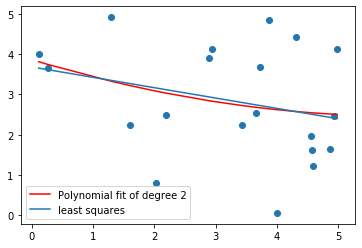

In [13]:
degree = 2 # Degree of the polynomial
coefficients2 = np.polyfit(X, Y, degree)
polynomial2 = np.poly1d(coefficients2)
y_pred2 = polynomial2(X)
plt.plot(X, y_pred2, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
plt.legend()
plt.show()

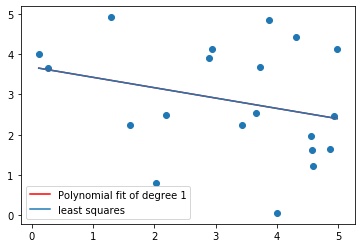

In [14]:
degree = 1 # Degree of the polynomial
coefficients1 = np.polyfit(X, Y, degree)
polynomial1 = np.poly1d(coefficients1)
y_pred1 = polynomial1(X)
plt.plot(X, y_pred1, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
plt.legend()
plt.show()

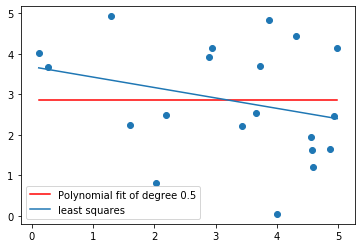

In [15]:
degree = 0.5 # Degree of the polynomial
coefficientspt5 = np.polyfit(X, Y, degree)
polynomialpt5 = np.poly1d(coefficientspt5)
y_predpt5 = polynomialpt5(X)
plt.plot(X, y_predpt5, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
plt.legend()
plt.show()

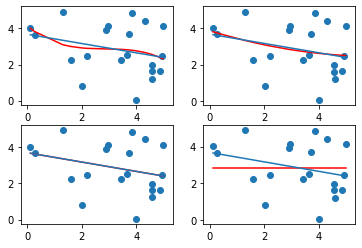

In [16]:
plt.subplot(2, 2, 1) # (row, column, active area)
plt.plot(X, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
# plt.legend()

plt.subplot(2, 2, 2)
plt.plot(X, y_pred2, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
# plt.legend()

plt.subplot(2, 2, 3) # (row, column, active area)
plt.plot(X, y_pred1, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
# plt.legend()

plt.subplot(2, 2, 4)
plt.plot(X, y_predpt5, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
# plt.legend()

plt.show()

3rd, 2nd, 1st (least squares line), and 0.5 degree (out of curiosity) degree polynomials shown side by side. It's clear that the 0.5 degree polynomial is underfitting because there is no variation in the line, appearing to not have a slope. The r-value of this line is 0.

In [17]:
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared 3rd degree POLYNOMIAL: {r_squared:.4f}')

mse = np.mean((Y - y_pred)**2)
print(f'Mean Squared Error 3rd degree POLYNOMIAL: {mse:.4f}')

ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred2)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared 2nd degree POLYNOMIAL: {r_squared:.4f}')

mse = np.mean((Y - y_pred2)**2)
print(f'Mean Squared Error 2nd degree POLYNOMIAL: {mse:.4f}')

ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred1)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared 1st degree POLYNOMIAL: {r_squared:.4f}')

mse = np.mean((Y - y_pred1)**2)
print(f'Mean Squared Error 1st degree POLYNOMIAL: {mse:.4f}')

ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_predpt5)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared 0.5 degree POLYNOMIAL: {r_squared:.4f}')

mse = np.mean((Y - y_predpt5)**2)
print(f'Mean Squared Error 0.5 degree POLYNOMIAL: {mse:.4f}')

R-squared 3rd degree POLYNOMIAL: 0.0912
Mean Squared Error 3rd degree POLYNOMIAL: 1.7046
R-squared 2nd degree POLYNOMIAL: 0.0814
Mean Squared Error 2nd degree POLYNOMIAL: 1.7230
R-squared 1st degree POLYNOMIAL: 0.0781
Mean Squared Error 1st degree POLYNOMIAL: 1.7291
R-squared 0.5 degree POLYNOMIAL: -0.0000
Mean Squared Error 0.5 degree POLYNOMIAL: 1.8756


In [18]:
degree = 3
V = np.vander(X, N=degree+1, increasing=True)
print(V)

[[1.00000000e+00 1.13472815e-01 1.28760799e-02 1.46108503e-03]
 [1.00000000e+00 2.71563072e-01 7.37465019e-02 2.00268266e-02]
 [1.00000000e+00 1.30023018e+00 1.69059853e+00 2.19816723e+00]
 [1.00000000e+00 1.59442172e+00 2.54218063e+00 4.05330801e+00]
 [1.00000000e+00 2.02525630e+00 4.10166310e+00 8.30691906e+00]
 [1.00000000e+00 2.19046848e+00 4.79815215e+00 1.05102010e+01]
 [1.00000000e+00 2.88940463e+00 8.34865910e+00 2.41226542e+01]
 [1.00000000e+00 2.94806380e+00 8.69108016e+00 2.56218588e+01]
 [1.00000000e+00 3.42561757e+00 1.17348557e+01 4.01991280e+01]
 [1.00000000e+00 3.65082683e+00 1.33285366e+01 4.86601790e+01]
 [1.00000000e+00 3.71815414e+00 1.38246702e+01 5.14022550e+01]
 [1.00000000e+00 3.86308591e+00 1.49234328e+01 5.76505029e+01]
 [1.00000000e+00 4.00547874e+00 1.60438599e+01 6.42633398e+01]
 [1.00000000e+00 4.31128538e+00 1.85871816e+01 8.01346442e+01]
 [1.00000000e+00 4.56193225e+00 2.08112259e+01 9.49394025e+01]
 [1.00000000e+00 4.57333101e+00 2.09153565e+01 9.565284

In [19]:
# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, Y)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)
print(coefficients)

[ 4.14940927 -1.29604961  0.44480151 -0.05187023]


In [20]:
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)
# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)


# same coefficients but reverse order!

Polynomial Coefficients:  [-0.05187023  0.44480151 -1.29604961  4.14940927]
